# Asignación de Polos — Diseño de Controladores

Este notebook muestra cómo usar la función `asigne_polos` para diseñar un controlador
por asignación de polos mediante la **matriz de Sylvester**, y visualizar los resultados.

**Esquema de control (realimentación unitaria):**

```
  r ──►(+)──► C(s) ──► G(s) ──► y
        ▲ −                │
        └──────────────────┘
```


In [1]:
!pip install control
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

!rm -f ubicarpolos.py && wget -O ubicarpolos.py https://raw.githubusercontent.com/nebisman/control-material/refs/heads/main/notebooks/ubicarpolos.py
from ubicarpolos import asigne_polos

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
    'font.size': 11,
})


  Using cached control-0.10.2-py3-none-any.whl.metadata (7.6 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached control-0.10.2-py3-none-any.whl (578 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 32.5 MB/s  0:00:00 eta 0:00:01
Using cached contourp

## 1. Definimos la planta



$$G(s) = \frac{2}{s^3 + 6s^2 + 11s + 6} = \frac{2}{(s+1)(s+2)(s+3)}$$

Polos deseados: $\{-8,\; -9, \; -10\; -2 \pm 2j\}$ (5 polos → controlador mínimo de orden 2).


In [2]:
G=ctrl.tf([1.15, 0.17], [1, 0.73, 0.92, 0])
print("Planta P(s):")
print(G)
print(f"Polos: {ctrl.poles(G)}")


Planta P(s):
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       1.15 s + 0.17
  -----------------------
  s^3 + 0.73 s^2 + 0.92 s
Polos: [-0.365+0.88700338j -0.365-0.88700338j  0.   +0.j        ]


## 2. Elegir los polos deseados

Para una planta de orden $n = 3$, necesitamos al menos $2n - 1 = 5$ polos para un controlador de orden minimo. Por ejemplo:
$$s_1 = -10 , s_2= -9, s_3=-8,  \quad s_{4,5} = -2 \pm 2j$$


In [37]:
wn=.45
z=0.7
polos_deseados = [-z*wn+1j*wn*np.sqrt(1-z**2),-z*wn-1j*wn*np.sqrt(1-z**2), -2*wn,-2.1*wn,-2.2*wn]

print(f"Polos deseados: {polos_deseados}")


Polos deseados: [(-0.315+0.32136427928442823j), (-0.315-0.32136427928442823j), -0.9, -0.9450000000000001, -0.9900000000000001]


## 3. Diseñar el controlador

In [38]:
C, T, Gur, S, err = asigne_polos(G, polos_deseados)

print("Controlador C(s):")
print(C)
print()
print("Lazo cerrado T(s):")
print(T)
print(f"\nPolos obtenidos: {np.round(ctrl.poles(T), 4)}")


0 states have been removed from the model
1 states have been removed from the model
0 states have been removed from the model
Controlador C(s):
<TransferFunction>: sys[110]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1.656 s^2 + 0.3636 s + 1.003
  ----------------------------
     s^2 + 2.735 s - 0.1551

Lazo cerrado T(s):
<TransferFunction>: sys[114]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          1.904 s^3 + 0.6996 s^2 + 1.215 s + 0.1705
  ----------------------------------------------------------
  s^5 + 3.465 s^4 + 4.666 s^3 + 3.103 s^2 + 1.073 s + 0.1705

Polos obtenidos: [-0.99 +0.j     -0.945+0.j     -0.9  +0.j     -0.315+0.3214j
 -0.315-0.3214j]


## 4. Respuesta al escalón

Obtenemos la respuesta en lazo cerrado del sistema.


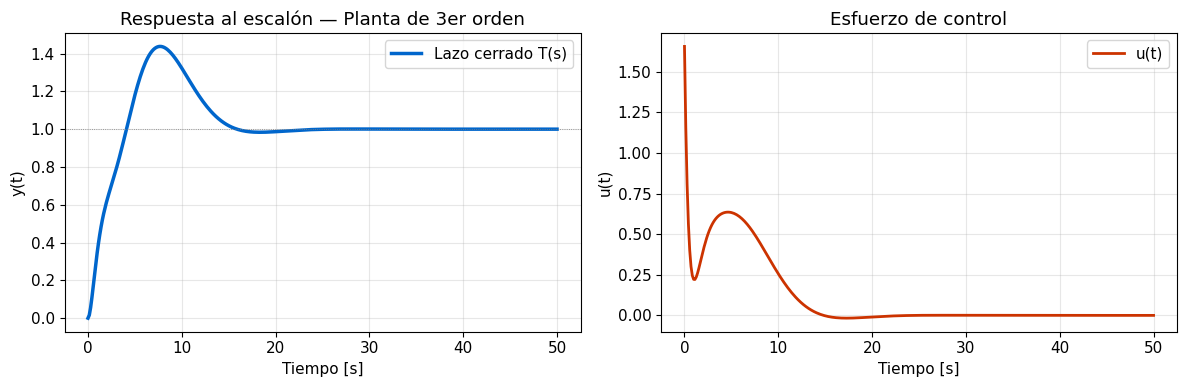

In [ ]:
# respuesta al escalón
t_cl, y_cl = ctrl.step_response(T,50)



fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t_u, y_u = ctrl.step_response(Gur, t_cl)

ax = axes[0]
ax.plot(t_cl, y_cl, "-",  color="#0066cc", lw=2.5, label="Lazo cerrado T(s)")
ax.axhline(1, color="gray", lw=0.6, ls=":")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("y(t)")
ax.set_title("Respuesta al escalón — Planta de 3er orden")
ax.legend()

ax = axes[1]
ax.plot(t_u, y_u, "-", color="#cc3300", lw=2, label="u(t)")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("u(t)")
ax.set_title("Señal de  control")
ax.legend()
plt.tight_layout()
plt.show()


# Actividad: rediseñar los controladores para que la tengan:
- Error de posición cero
- Error de velocidad cero

